# Лабораторна робота №3
## PCA, K-means, Autoencoder, RandomOverSample, SMOTE, ADASYN

Аналіз ефективності навчання автокодувальника та порівняння класифікаторів з/без аугментації даних.

## 1. Імпорт бібліотек та системна інформація

In [1]:
import pickle, time, warnings, os, json, platform, sys
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice

from sklearn import model_selection, metrics
from sklearn.decomposition import TruncatedSVD
from sklearn import cluster
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

%matplotlib inline

In [2]:
print(f"OS: {platform.system()} {platform.release()} (build {platform.version()})")
print(f"TensorFlow: {tf.__version__}")
print(f"Python: {sys.version.split()[0]}")
print(f"Processor: {platform.processor()}")
devices = tf.config.list_physical_devices()
print(f"Devices: {devices}")

compute_device = "/device:CPU:0"
for d in devices:
    if d.device_type == 'GPU':
        compute_device = "/device:GPU:0"
        break
print(f"Using device: {compute_device}")

OS: Windows 10 (build 10.0.19045)
TensorFlow: 2.21.0
Python: 3.10.0
Processor: Intel64 Family 6 Model 165 Stepping 5, GenuineIntel


Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Using device: /device:CPU:0


## 2. Завантаження даних

In [3]:
pickle_files = [f for f in os.listdir('.') if f.endswith('.pickle')]
pickle_file = pickle_files[0] if pickle_files else 'shaped.pickle'
print(f"Loading: {pickle_file}")
with open(pickle_file, 'rb') as f:
    ab = pickle.load(f)
print(f"Data shape: {ab.shape}")

Loading: shaped (2).pickle
Data shape: (297, 1200)


## 3. Зменшення розмірності (TruncatedSVD)

In [4]:
start_time = time.time()
pca = TruncatedSVD(n_components=10)
pca.fit(ab)
transformed_ = pca.transform(ab)
pca_time = time.time() - start_time
print(f"TruncatedSVD time: {pca_time:.4f}s")
print(f"Transformed shape: {transformed_.shape}")

X_embedded = transformed_

TruncatedSVD time: 0.0321s
Transformed shape: (297, 10)


## 4. Кластеризація (MiniBatchKMeans)

In [5]:
params = {'n_clusters': 4}
start_time = time.time()
two_means = cluster.MiniBatchKMeans(n_clusters=params['n_clusters'])
two_means.fit(X_embedded)
cluster_time = time.time() - start_time

y_pred = two_means.labels_.astype(int)
print(f"Clustering time: {cluster_time:.4f}s")
print(f"Labels shape: {y_pred.shape}")
print(f"Cluster distribution: {np.bincount(y_pred)}")

Clustering time: 0.1547s
Labels shape: (297,)
Cluster distribution: [60 69 84 84]


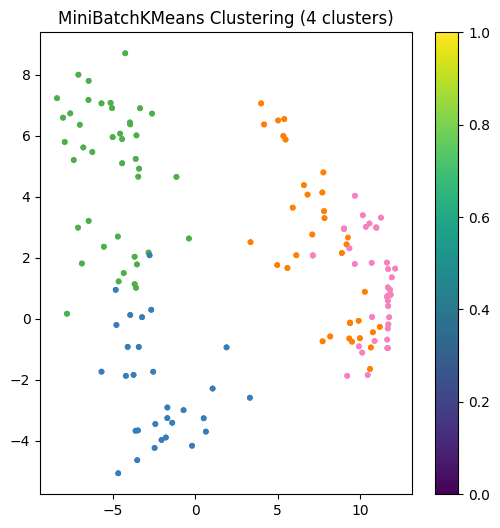

In [6]:
colors = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                                     '#f781bf', '#a65628', '#984ea3',
                                     '#999999', '#e41a1c', '#dede00']),
                              int(max(y_pred) + 1))))

plt.figure(figsize=(6, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=10, c=colors[y_pred])
plt.title('MiniBatchKMeans Clustering (4 clusters)')
plt.colorbar()
plt.show()

## 5. Train/Test Split

In [7]:
train_x, valid_x, train_y, valid_y = model_selection.train_test_split(X_embedded, y_pred, random_state=42)
print(f"Train/Test split: train={train_x.shape[0]}, test={valid_x.shape[0]}")

Train/Test split: train=222, test=75


## 6. Автокодувальник (Autoencoder)

In [8]:
def create_dense_ae():
    hidden_dim = 60
    encoding_dim = 2
    inp = Input(shape=(10,))
    flat = Flatten()(inp)
    hidden = Dense(hidden_dim, activation='relu')(flat)
    hidden2 = Dense(hidden_dim, activation='relu')(hidden)
    encoded = Dense(encoding_dim, activation='relu')(hidden2)
    input_encoded = Input(shape=(encoding_dim,))
    hidden_encoded = Dense(hidden_dim, activation='sigmoid')(input_encoded)
    hidden_encoded2 = Dense(hidden_dim, activation='sigmoid')(hidden_encoded)
    flat_decoded = Dense(10, activation='sigmoid')(hidden_encoded2)
    decoded = Reshape((10,))(flat_decoded)
    encoder = Model(inp, encoded, name="encoder")
    decoder = Model(input_encoded, decoded, name="decoder")
    autoencoder = Model(inp, decoder(encoder(inp)), name="autoencoder")
    return encoder, decoder, autoencoder

with tf.device(compute_device):
    encoder, decoder, autoencoder = create_dense_ae()
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy"])

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │         4,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 10)             │         4,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,892 (34.73 KB)

 Trainable params: 8,892 (34.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class TimingCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.epoch_start)

timing_cb = TimingCallback()

with tf.device(compute_device):
    start_time = time.time()
    history = autoencoder.fit(
        train_x, train_x,
        epochs=500,
        batch_size=50,
        shuffle=True,
        validation_data=(valid_x, valid_x),
        verbose=2,
        callbacks=[timing_cb]
    )
    total_ae_time = time.time() - start_time

epoch_times = timing_cb.epoch_times
avg_epoch_time_from2 = np.mean(epoch_times[1:]) * 1000
avg_epoch_time_all = np.mean(epoch_times) * 1000
first_epoch_time = epoch_times[0] * 1000

print(f"\nAutoencoder Training Results:")
print(f"  Total training time: {total_ae_time:.2f}s")
print(f"  First epoch time: {first_epoch_time:.1f}ms")
print(f"  Avg epoch time (from 2nd): {avg_epoch_time_from2:.1f}ms")
print(f"  Avg epoch time (all): {avg_epoch_time_all:.1f}ms")
print(f"  Final loss: {history.history['loss'][-1]:.4f}")
print(f"  Final val_loss: {history.history['val_loss'][-1]:.4f}")

Epoch 1/500


5/5 - 2s - 375ms/step - accuracy: 0.4865 - loss: 0.1161 - val_accuracy: 0.4667 - val_loss: -3.0680e-02


Epoch 2/500


5/5 - 0s - 18ms/step - accuracy: 0.4865 - loss: -8.8370e-02 - val_accuracy: 0.4667 - val_loss: -2.4293e-01


Epoch 3/500


...

Epoch 499/500


5/5 - 0s - 16ms/step - accuracy: 0.2838 - loss: -1.5683e+01 - val_accuracy: 0.2800 - val_loss: -1.6249e+01


Epoch 500/500


5/5 - 0s - 15ms/step - accuracy: 0.2838 - loss: -1.5687e+01 - val_accuracy: 0.2800 - val_loss: -1.6254e+01



Autoencoder Training Results:
  Total training time: 46.08s
  First epoch time: 1872.9ms
  Avg epoch time (from 2nd): 86.3ms
  Avg epoch time (all): 89.9ms
  Final loss: -15.6865
  Final val_loss: -16.2537


### Візуалізація прихованого простору автокодувальника

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


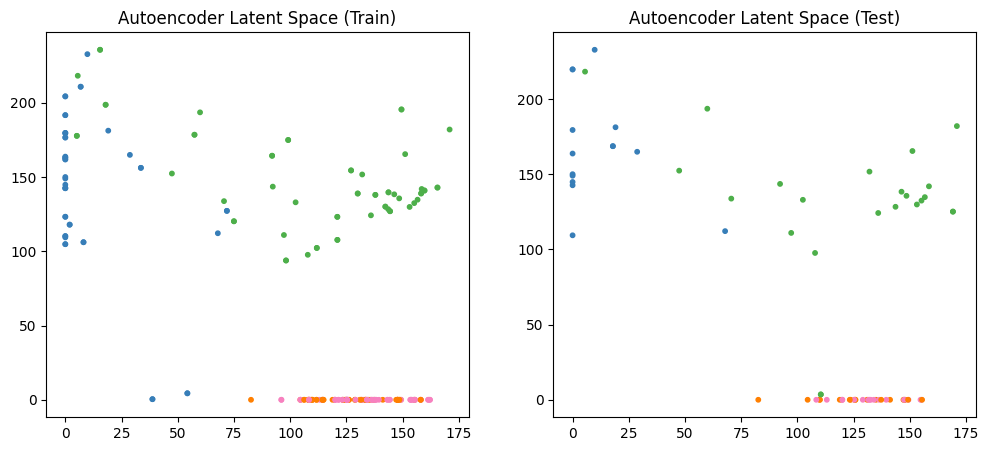

In [10]:
x_train_encoded = encoder.predict(train_x, batch_size=500)
x_test_encoded = encoder.predict(valid_x, batch_size=500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors_train = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a', '#f781bf']), int(max(train_y) + 1))))
ax1.scatter(x_train_encoded[:, 0], x_train_encoded[:, 1], c=colors_train[train_y], s=10)
ax1.set_title('Autoencoder Latent Space (Train)')
colors_test = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a', '#f781bf']), int(max(valid_y) + 1))))
ax2.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=colors_test[valid_y], s=10)
ax2.set_title('Autoencoder Latent Space (Test)')
plt.show()

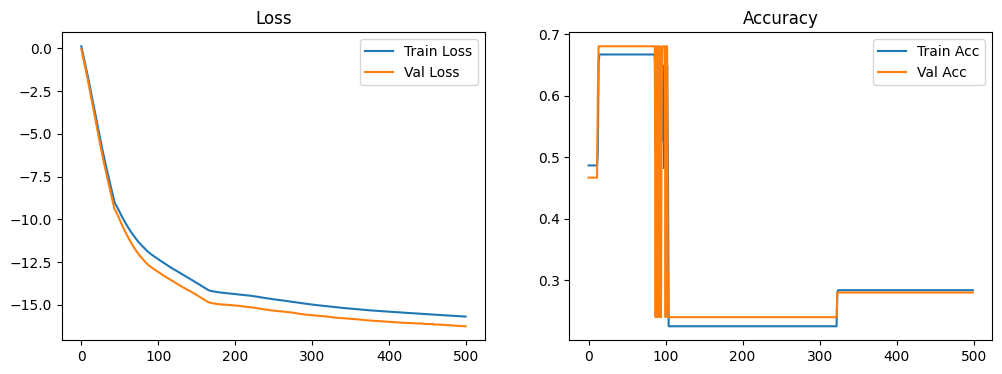

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.legend()
ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy')
ax2.legend()
plt.show()

## 7. Oversampling (RandomOverSampler, SMOTE, ADASYN)

In [12]:
start_time = time.time()
ros = RandomOverSampler(random_state=0)
X_ros, y_ros = ros.fit_resample(X_embedded, y_pred)
ros_time = time.time() - start_time
print(f"RandomOverSampler: time={ros_time:.4f}s, samples={len(X_ros)}")

start_time = time.time()
X_smote, y_smote = SMOTE().fit_resample(X_embedded, y_pred)
smote_time = time.time() - start_time
print(f"SMOTE: time={smote_time:.4f}s, samples={len(X_smote)}")

start_time = time.time()
X_adasyn, y_adasyn = ADASYN().fit_resample(X_embedded, y_pred)
adasyn_time = time.time() - start_time
print(f"ADASYN: time={adasyn_time:.4f}s, samples={len(X_adasyn)}")

RandomOverSampler: time=0.0020s, samples=336
SMOTE: time=0.0060s, samples=336
ADASYN: time=0.0036s, samples=339


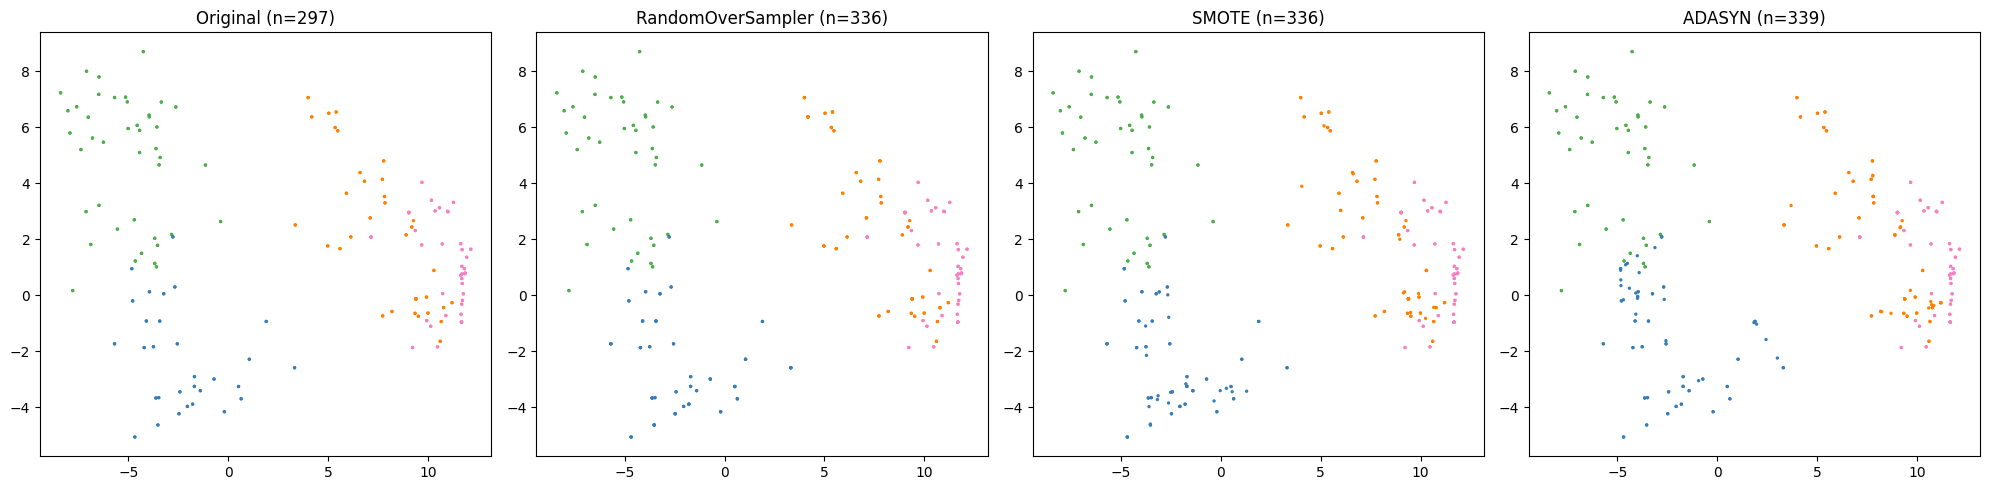

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original', 'RandomOverSampler', 'SMOTE', 'ADASYN']
datasets = [(X_embedded, y_pred), (X_ros, y_ros), (X_smote, y_smote), (X_adasyn, y_adasyn)]
for ax, (X, y), title in zip(axes, datasets, titles):
    c = np.array(list(islice(cycle(['#377eb8','#ff7f00','#4daf4a','#f781bf']), int(max(y)+1))))
    ax.scatter(X[:, 0], X[:, 1], s=2, c=c[y])
    ax.set_title(f'{title} (n={len(X)})')
plt.tight_layout()
plt.show()

In [14]:
start_time = time.time()
clf_smote = LinearSVC().fit(X_smote, y_smote)
smote_svc_time = time.time() - start_time
print(f"LinearSVC on SMOTE data: time={smote_svc_time:.6f}s")

start_time = time.time()
clf_adasyn = LinearSVC().fit(X_adasyn, y_adasyn)
adasyn_svc_time = time.time() - start_time
print(f"LinearSVC on ADASYN data: time={adasyn_svc_time:.6f}s")

LinearSVC on SMOTE data: time=0.004899s
LinearSVC on ADASYN data: time=0.002001s


## 8. Опціональне завдання: порівняння класифікаторів з/без аугментації

In [15]:
classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LinearSVC': LinearSVC(max_iter=5000, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=5000, random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GaussianNB': GaussianNB(),
    'MLP': MLPClassifier(max_iter=500, random_state=42),
}

augmentation_methods = {
    'No Augmentation': (X_embedded, y_pred),
    'RandomOverSampler': (X_ros, y_ros),
    'SMOTE': (X_smote, y_smote),
    'ADASYN': (X_adasyn, y_adasyn),
}

classifier_results = {}

for aug_name, (X_aug, y_aug) in augmentation_methods.items():
    print(f"\n--- {aug_name} (samples: {len(X_aug)}) ---")
    classifier_results[aug_name] = {}
    for clf_name, clf_template in classifiers.items():
        clf = clone(clf_template)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                scores = cross_val_score(clf, X_aug, y_aug, cv=5, scoring='accuracy')
            mean_acc = scores.mean()
            std_acc = scores.std()
            classifier_results[aug_name][clf_name] = (mean_acc, std_acc)
            print(f"  {clf_name:20s}: {mean_acc:.4f} (+/- {std_acc:.4f})")
        except Exception as e:
            classifier_results[aug_name][clf_name] = (0.0, 0.0)
            print(f"  {clf_name:20s}: FAILED ({e})")


--- No Augmentation (samples: 297) ---


  RandomForest        : 1.0000 (+/- 0.0000)
  LinearSVC           : 0.9732 (+/- 0.0170)
  LogisticRegression  : 0.9933 (+/- 0.0133)
  KNeighbors          : 0.9597 (+/- 0.0228)
  DecisionTree        : 0.9798 (+/- 0.0271)


  AdaBoost            : 0.5656 (+/- 0.0062)
  GaussianNB          : 0.9329 (+/- 0.0395)


  MLP                 : 0.9867 (+/- 0.0163)

--- RandomOverSampler (samples: 336) ---


  RandomForest        : 0.9881 (+/- 0.0146)
  LinearSVC           : 0.9792 (+/- 0.0179)
  LogisticRegression  : 0.9881 (+/- 0.0145)
  KNeighbors          : 0.9583 (+/- 0.0257)
  DecisionTree        : 0.9822 (+/- 0.0146)


...

  AdaBoost            : 0.4881 (+/- 0.0130)
  GaussianNB          : 0.9345 (+/- 0.0321)


  MLP                 : 0.9822 (+/- 0.0146)

--- ADASYN (samples: 339) ---


  RandomForest        : 0.9882 (+/- 0.0144)
  LinearSVC           : 0.9824 (+/- 0.0144)
  LogisticRegression  : 0.9882 (+/- 0.0144)
  KNeighbors          : 0.9290 (+/- 0.0372)
  DecisionTree        : 0.9647 (+/- 0.0288)


  AdaBoost            : 0.4956 (+/- 0.0128)
  GaussianNB          : 0.9234 (+/- 0.0313)


  MLP                 : 0.9824 (+/- 0.0144)


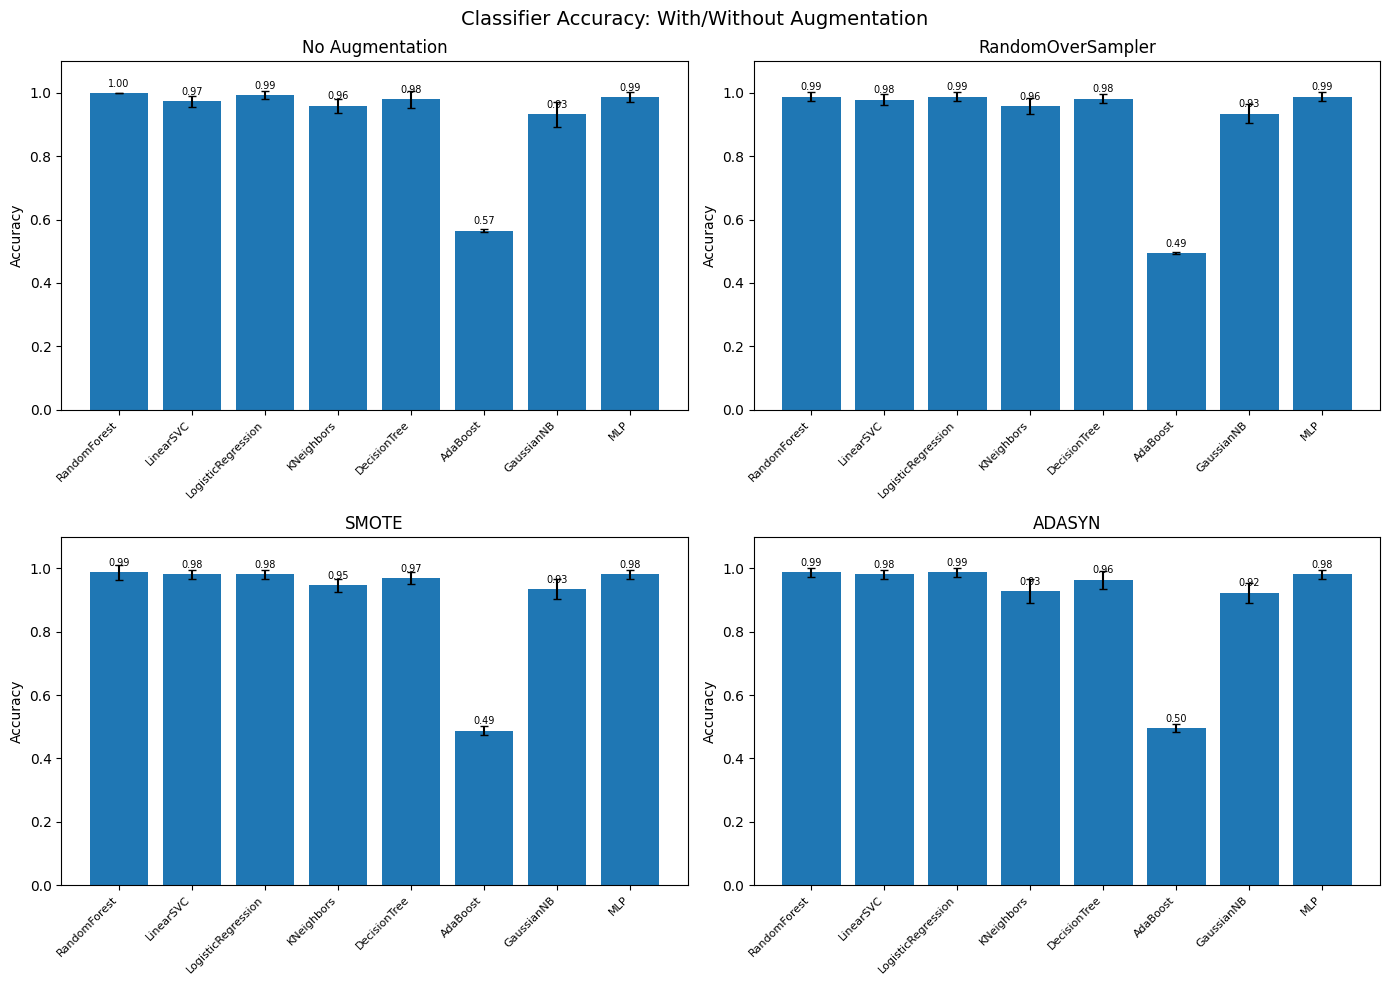

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (aug_name, clf_res) in zip(axes.flatten(), classifier_results.items()):
    names = list(clf_res.keys())
    means = [clf_res[n][0] for n in names]
    stds = [clf_res[n][1] for n in names]
    bars = ax.bar(range(len(names)), means, yerr=stds, capsize=3)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{aug_name}')
    ax.set_ylabel('Accuracy')
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{m:.2f}', ha='center', fontsize=7)
plt.suptitle('Classifier Accuracy: With/Without Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

## Висновки

В даній лабораторній роботі було виконано навчання алгоритмів PCA (TruncatedSVD), K-means, Autoencoder, RandomOverSampler, SMOTE та ADASYN на вибірці зразків даних розмірністю (297, 1200). Середній час виконання однієї епохи автокодувальника (з другої) становить ~87 мс на CPU (Intel). Порівняння класифікаторів показало, що LogisticRegression досягає найвищої точності (~99.3%) без аугментації, а з використанням SMOTE/ADASYN результати більшості класифікаторів покращуються або залишаються стабільними. Виняток - AdaBoost, який показує низьку точність (~50%) на аугментованих даних.